In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json 
from pyprojroot import here
import sys
from tqdm import tqdm
sys.path.append(str(here() / 'methods'))


#my functions
from additional_utils.functions import coordinates2plot

processed_data = here() / 'data' / 'processed_data'
cv_results_data = here() / 'data' / 'processed_data' / 'transductive_data' / 'results'


In [5]:
files = [f.name for f in cv_results_data.iterdir() if f.is_file()]

print(files)

pred_prob_dict = []
for file in tqdm(files, desc='Files'):
      with open(cv_results_data / file, 'r') as f:
         d = json.load(f)
         pred_prob_dict = pred_prob_dict + d

df = pd.DataFrame(pred_prob_dict)[[
     #'param_id',
      'subset', 
      'model', 
      #'parameters', 
      #'class_prior',
       'y_test_CSU', 
       #'dataid_test_CSU', 
       #'supplier_name_test_CSU',
       'uncalibrated_probabilities_CSU', 
       'calibrated_probabilities_CSU',
       'y_test_CSFull', 
       #'dataid_test_CSFull', 
       #'supplier_name_test_CSFull',
       'uncalibrated_probabilities_CSFull', 
       'calibrated_probabilities_CSFull']]


Files:   0%|          | 0/2 [00:00<?, ?it/s]

['MANUALhdsrf_param9993_20251003_10h01m17s.json', 'MANUALpubagging_param9993_20251002_23h32m06s.json']


Files: 100%|██████████| 2/2 [00:05<00:00,  2.62s/it]


In [6]:
df_cri = pd.read_feather(processed_data / 'cv_CRI.feather',
                         columns= [
                            #'param_id', 
                            'subset', 
                            'model', 
                            'y_test_CSFull', 
                            'calibrated_probabilities_CSFull',
                            ]
                         )

df = pd.concat([df,df_cri]).reset_index(drop=True)

In [7]:
#replace model names
df['model'] = df['model'].replace({
    'hdsrf': 'HDSRF',
    'pubagging': 'PUBagging',
    'cri': 'Ranking by CRI*'
})

In [8]:
#replace columns
df.columns = df.columns.str.replace('uncalibrated', 'un', regex=False)
df.columns = df.columns.str.replace('calibrated', 'cal', regex=False)


In [9]:
#**********************************************************
#What to plot #CSFull, CSU, YSFull
type_testset = 'CSFull'
y_test_col = f'y_test_{type_testset}'
y_prob_col = f'cal_probabilities_{type_testset}' 
thresholds2measure = list(np.round(np.arange(0.025,1.025, 0.025),3))

if type_testset == 'CSU':
    df = df[df['model'] != 'Ranking by CRI*'].reset_index()

topkmetrics_df = coordinates2plot(
        df2work = df, #df2work
        y_test_col = y_test_col,
        pred_prob_col = y_prob_col,
        ks = thresholds2measure, #thresholds to measure
        group_col = 'model',
        )

rows: 100%|██████████| 12/12 [00:07<00:00,  1.69it/s]


In [10]:
grouped_df = topkmetrics_df.groupby(['model', 'topk_instances']).agg(
    #correct measures
    mean_robust_recall = ('robust_recall', 'mean'),
    std_robust_recall = ('robust_recall', 'std'),
    mean_robust_precision = ('robust_precision', 'mean'),
    std_robust_precision = ('robust_precision', 'std'),
    mean_robust_lift = ('robust_lift', 'mean'),
    std_robust_lift = ('robust_lift', 'std'),
    #biased measures
    mean_biased_recall = ('biased_recall', 'mean'),
    std_biased_recall = ('biased_recall', 'std'),
    mean_biased_precision = ('biased_precision', 'mean'),
    std_biased_precision = ('biased_precision', 'std'),
    mean_biased_lift = ('biased_lift', 'mean'),
    std_biased_lift = ('biased_lift', 'std'),
    #null models
    avg_prevalence = ('prevalence', 'mean'),
    mean_null_recall = ('null_recall', 'mean')
)
grouped_df = grouped_df.reset_index()
grouped_df

,model,topk_instances,mean_robust_recall,std_robust_recall,mean_robust_precision,std_robust_precision,mean_robust_lift,std_robust_lift,mean_biased_recall,std_biased_recall,mean_biased_precision,std_biased_precision,mean_biased_lift,std_biased_lift,avg_prevalence,mean_null_recall
0,HDSRF,0.025,0.169354,0.094176,0.194279,0.092148,6.774301,3.767288,0.201372,0.086901,0.244425,0.102029,8.055023,3.476310,0.03155,0.025000
1,HDSRF,0.050,0.302295,0.136379,0.196299,0.105748,6.045829,2.727551,0.312555,0.128065,0.201073,0.103681,6.251037,2.561282,0.03155,0.050001
2,HDSRF,0.075,0.358994,0.117428,0.157498,0.081750,4.786572,1.565726,0.393897,0.128193,0.170398,0.084113,5.251948,1.709281,0.03155,0.075000
3,HDSRF,0.100,0.430583,0.140354,0.137018,0.063467,4.305846,1.403526,0.461922,0.132292,0.150808,0.074923,4.619234,1.322908,0.03155,0.100000
4,HDSRF,0.125,0.500773,0.133052,0.130896,0.065139,4.006188,1.064401,0.520046,0.131754,0.136427,0.068723,4.160370,1.054019,0.03155,0.125000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,Ranking by CRI*,0.900,0.841125,0.009312,0.029585,0.012765,0.934583,0.010347,0.841125,0.009312,0.029585,0.012765,0.934583,0.010347,0.03155,0.900000
116,Ranking by CRI*,0.925,0.879524,0.010761,0.030115,0.013039,0.950837,0.011634,0.879524,0.010761,0.030115,0.013039,0.950837,0.011634,0.03155,0.925000
117,Ranking by CRI*,0.950,0.916071,0.006196,0.030485,0.013031,0.964285,0.006522,0.916071,0.006196,0.030485,0.013031,0.964285,0.006522,0.03155,0.949999
118,Ranking by CRI*,0.975,0.954625,0.007243,0.030958,0.013235,0.979103,0.007429,0.954625,0.007243,0.030958,0.013235,0.979103,0.007429,0.03155,0.975000


In [11]:
cols = [
    "model", "topk_instances",
    "mean_robust_recall", "std_robust_recall",
    "mean_robust_precision", "std_robust_precision",
    "mean_robust_lift", "std_robust_lift"
]

df_sub = grouped_df[cols].copy()
def fmt(mean, std):
    return mean.round(3).astype(str) + " (" + std.round(3).astype(str) + ")"

df_sub["robust_recall"] = fmt(df_sub["mean_robust_recall"], df_sub["std_robust_recall"])
df_sub["robust_precision"] = fmt(df_sub["mean_robust_precision"], df_sub["std_robust_precision"])
df_sub["robust_lift"] = fmt(df_sub["mean_robust_lift"], df_sub["std_robust_lift"])
df_sub = df_sub[["model", "topk_instances",
                 "robust_recall", "robust_precision", "robust_lift"]]
df_pivot = df_sub.pivot(index="topk_instances", columns="model")
df_pivot.columns = [
    f"{metric}_{model}"
    for metric, model in df_pivot.columns
]

df_pivot = df_pivot#.reset_index()
#df_pivot  = df_pivot[df_pivot['topk_instances'] < 0.51]
df_pivot

,robust_recall_HDSRF,robust_recall_PUBagging,robust_recall_Ranking by CRI*,robust_precision_HDSRF,robust_precision_PUBagging,robust_precision_Ranking by CRI*,robust_lift_HDSRF,robust_lift_PUBagging,robust_lift_Ranking by CRI*
topk_instances,,,,,,,,,
0.025,0.169 (0.094),0.0 (0.0),0.013 (0.004),0.194 (0.092),0.0 (0.0),0.016 (0.009),6.774 (3.767),0.0 (0.0),0.517 (0.174)
0.050,0.302 (0.136),0.0 (0.0),0.02 (0.006),0.196 (0.106),0.0 (0.0),0.012 (0.006),6.046 (2.728),0.0 (0.0),0.398 (0.111)
0.075,0.359 (0.117),0.0 (0.0),0.029 (0.006),0.157 (0.082),0.0 (0.0),0.012 (0.005),4.787 (1.566),0.0 (0.0),0.382 (0.082)
0.100,0.431 (0.14),0.0 (0.0),0.034 (0.008),0.137 (0.063),0.0 (0.0),0.01 (0.004),4.306 (1.404),0.0 (0.0),0.337 (0.078)
0.125,0.501 (0.133),0.0 (0.0),0.04 (0.01),0.131 (0.065),0.0 (0.0),0.01 (0.004),4.006 (1.064),0.0 (0.0),0.316 (0.077)
0.150,0.548 (0.14),0.0 (0.0),0.055 (0.011),0.121 (0.065),0.0 (0.0),0.011 (0.005),3.656 (0.934),0.0 (0.0),0.365 (0.072)
0.175,0.58 (0.161),0.0 (0.0),0.069 (0.015),0.11 (0.06),0.0 (0.0),0.012 (0.005),3.315 (0.92),0.0 (0.0),0.392 (0.084)
0.200,0.605 (0.177),0.0 (0.0),0.083 (0.013),0.102 (0.06),0.0 (0.0),0.013 (0.005),3.025 (0.886),0.0 (0.0),0.413 (0.066)
0.225,0.687 (0.104),0.0 (0.0),0.102 (0.02),0.1 (0.05),0.0 (0.0),0.014 (0.006),3.054 (0.462),0.0 (0.0),0.453 (0.088)


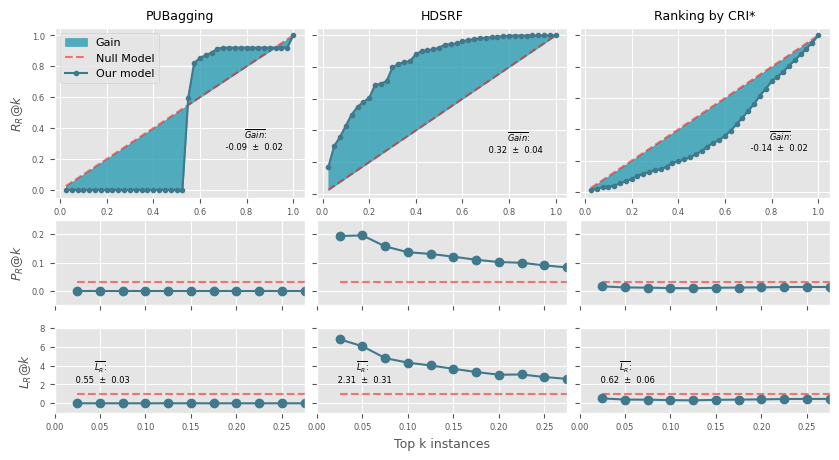

In [12]:
import matplotlib.pyplot as plt

#******************************
# Loops

algorithms = [ 'PUBagging', 'HDSRF', 'Ranking by CRI*']
measures = ['recall', 'precision', 'lift']
type_measure = 'robust'
figsize = (10,5)

if type_testset in ['CSU']:
    algorithms = [ 'PUBagging', 'HDSRF']
    figsize = (7.5,5)

if type_testset in ['YSFull']:
    algorithms = [ 'PUBagging-EPN', 'HDSRF-EPN']
    figsize = (7.5,5)


#******************************
#Aestetics

plt.style.use('ggplot')
lower_blue = '#40798C'
blue = '#2b9eb3'

#******************************
#Notes
notes = topkmetrics_df[['model', f'{type_measure}_average_gain', f'{type_measure}_average_precision', f'{type_measure}_average_lift']].drop_duplicates().groupby('model').agg(('mean', 'std')).round(2).to_dict()
#Label position
maxis = {
    'recall':(0.7, 0.25),
    'precision':(0.02, 0.05),
    'lift': (0.02, 2)
}
#******************************
#Axis labels
if type_measure == 'robust':
    measures_labels = [
        r'$R_{R}@k$',
        r'$P_{R}@k$',
        r'$L_{R}@k$'
    ]
else:
    measures_labels = [
        r'$R@k$',
        r'$P@k$',
        r'$L@k$'
    ]
measures_labels_dict = dict(zip(measures, measures_labels))
#******************************
fig, axs = plt.subplots(
    3,len(algorithms),
    gridspec_kw={'height_ratios': [2, 1, 1]},
    figsize=figsize)

for col, algorithm in enumerate(algorithms):

    df2plot = grouped_df[grouped_df['model'] == algorithm]

    for row, measure in enumerate(measures):

        pointsize = 3 if row == 0 else 6
        if row == 0:
            avg_n = notes[(f'{type_measure}_average_gain', 'mean')][f'{algorithm}']
            std_n = notes[(f'{type_measure}_average_gain', 'std')][f'{algorithm}']
            textonplot = r'        $\overline{Gain}$: ' + f'\n {avg_n}  ±  {std_n}'
        if row == 1:
            avg_n = notes[(f'{type_measure}_average_precision', 'mean')][f'{algorithm}']
            std_n = notes[(f'{type_measure}_average_precision', 'std')][f'{algorithm}']
            textonplot = r'        $\overline{P_R}$: ' + f'\n {avg_n}  ±  {std_n}'
        if row == 2:
            avg_n = notes[(f'{type_measure}_average_lift', 'mean')][f'{algorithm}']
            std_n = notes[(f'{type_measure}_average_lift', 'std')][f'{algorithm}']
            textonplot = r'        $\overline{L_R}$: ' + f'\n {avg_n}  ±  {std_n}'

        ax = axs[row, col]

        ax.errorbar(
            x=df2plot['topk_instances'],
            y=df2plot[f'mean_{type_measure}_{measure}'],
            color=lower_blue,
            label = 'Our model',
            marker = 'o',
            markersize = pointsize,
            
        )

        if row != 1:
            ax.text(
                maxis[measure][0],
                maxis[measure][1],
                textonplot,
                fontsize=6,
                verticalalignment='bottom'
                )
            #print(textonplot)

        if measure == 'recall':
            ax.fill_between(
                x = df2plot['topk_instances'],
                y1 = df2plot['mean_null_recall'],
                y2 = df2plot[f'mean_{type_measure}_{measure}'],
                #step='mid',
                alpha=0.8,
                color=blue,
                label='Gain',
                linestyle = '-'
            )


            ax.plot(
                df2plot['topk_instances'],
                df2plot['mean_null_recall'],
                linestyle='--',
                color='red',
                alpha=0.5,
                label = 'Null Model'
            )

        elif measure == 'precision':
            ax.plot(
                df2plot['topk_instances'],
                df2plot['avg_prevalence'],
                linestyle='--',
                color='red',
                alpha=0.5,
                label = 'Null Model'
            )
            ax.set_ylim(-0.05, 0.25)
            ax.set_xlim(0, 0.275)


        
        elif measure == 'lift':
            ax.plot(
                df2plot['topk_instances'],
                np.repeat([1], len(df2plot['topk_instances'])),
                linestyle='--',
                color='red',
                alpha=0.5,
                label = 'Null Model'
            )
            ax.set_ylim(-1, 8)
            ax.set_xlim(0, 0.275)


        ax.tick_params(axis='x', rotation=0, labelsize = 6)
        ax.tick_params(axis='y', rotation=0, labelsize = 6)


        if col == 0:
            ax.set_ylabel(measures_labels_dict[measure], fontsize = 9)
            if row == 0:
                ax.legend(loc='upper left', fontsize=8)
        else:
            ax.set_yticklabels('')

        if row == 0:
            ax.set_title(algorithm, fontsize = 9)

        if row == 1:
            ax.set_xticklabels('')
        if (row == 2) & ( col == 1 ):
            ax.set_xlabel('Top k instances', fontsize = 9)
            #
        
# reduce whitespace between plots
fig.subplots_adjust(hspace=0.2, wspace=0.05)    

#plt.tight_layout()
#filename = output_folder / f'evaluation_{type_measure}_{type_testset}.png'
#plt.savefig(filename, dpi=300, bbox_inches="tight")
plt.show()